# 量价因子截面选股研究 — v3 完整实验

**研究问题**：纯量价特征（OHLCV）能否在 S&P 500 上产生统计显著的截面选股信号？

**最终配置**：
- 特征：77 个 primitives × 变换树 → 1547 个特征，每个 fold 独立 IC 筛选 top-200
- 标签：行业中性化超额收益（个股收益 − 行业等权均值），预测窗口 H=5 交易日
- 模型：CatBoostRegressor，5-fold purged expanding walk-forward

**结果**：mean Rank IC = 0.0156，ICIR = 0.126，HAC t = 1.85，p = 0.032（单侧）


## 1. 环境与数据加载

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sp500_relative_alpha.daily_data_loader import ROUND1_SNAPSHOT_MANIFEST, load_round1_daily_ohlcv
from sp500_relative_alpha.folds import build_round1_walk_forward_folds, validate_fold_label_windows
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels
from sp500_relative_alpha.sector_data import build_sector_map
from sp500_relative_alpha.feature_transforms import TransformConfig, CrossCombinationSpec
from sp500_relative_alpha.research_dataset import build_v2_research_dataset
from sp500_relative_alpha.modeling import WalkForwardPredictionConfig, run_walk_forward_predictions
from sp500_relative_alpha.catboost_models import CatBoostRegressorConfig, CatBoostRegressorPredictor
from sp500_relative_alpha.metrics import RankICConfig, evaluate_oos_rank_ic

HORIZON = 5
EXCLUDED_SYMBOLS = ("HUBB",)
SECTOR_NEUTRAL_LABEL = "sector_relative_open_to_open_return"

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True


## 2. 股票数据概览

| 项目 | 配置 |
|---|---|
| 数据来源 | Databento，本地 parquet 快照 |
| 股票宇宙 | S&P 500 成分股，503 支（排除 SPY、HUBB） |
| 日期范围 | 2015-01-02 ~ 2026-03-31 |
| 数据粒度 | 日频 OHLCV |
| 基准 | SPY（用于 benchmark-relative 标签） |


In [2]:
manifest = pd.read_csv(ROUND1_SNAPSHOT_MANIFEST)
symbols = [s for s in manifest["symbol"].tolist() if s not in EXCLUDED_SYMBOLS]

daily_bars = load_round1_daily_ohlcv(symbols=symbols)
print(f"股票数量：{daily_bars['symbol'].nunique()}")
print(f"日期范围：{daily_bars['date'].min()} ~ {daily_bars['date'].max()}")
print(f"总行数：{len(daily_bars):,}")


股票数量：503
日期范围：2015-01-02 00:00:00 ~ 2026-03-31 00:00:00
总行数：1,375,565


## 3. 特征工程：变换树系统

### 设计思路

不手工设计因子，而是用**系统性变换**把少量原始变量扩展成大特征库，再用 IC 筛选有效特征。

```
原始变量（primitive）
    ↓ 一阶变换（8种）
    identity | cs_rank | ts_zscore(20,60,120) | ts_change(5,20,60)
    ↓ 二阶变换（12种）
    csr∘tsz | tsz∘csr | csr∘tc | tc∘csr（各时间窗口组合）
```

**两类关键变换的含义**：
- `cs_rank`（截面排名）：把绝对值转成"今天在全市场排第几"，消除量纲差异
- `ts_zscore`（时序 z-score）：把当前值转成"相对自己历史的偏离程度"，捕捉动量强弱

### 特征规模

| 类别 | Primitive 数 | 总特征数 |
|---|---|---|
| OHLCV 收益率/成交量/日内结构 | 25 | — |
| Alpha101（WorldQuant 101 中 OHLCV 子集） | 52 | — |
| **市场中性历史超额收益**（Optiver 思路） | 11 | — |
| **合计 → 变换后** | **77** | **1547** |

每个 fold 训练集内独立用截面 Pearson IC 筛选 top-200，**绝不使用测试集信息**。


In [3]:
CROSS_COMBINATIONS = (
    CrossCombinationSpec("ret_20d",        "volume_ratio_20d",  "mul", "ret20d_x_volr20d"),
    CrossCombinationSpec("ret_60d",        "volume_ratio_60d",  "mul", "ret60d_x_volr60d"),
    CrossCombinationSpec("ret_20d",        "high_low_range",    "sub", "ret20d_sub_hlr"),
    CrossCombinationSpec("ret_60d",        "high_low_range",    "sub", "ret60d_sub_hlr"),
    CrossCombinationSpec("ret_5d",         "ret_60d",           "sub", "ret5d_sub_ret60d"),
    CrossCombinationSpec("ret_20d",        "ret_252d",          "sub", "ret20d_sub_ret252d"),
    CrossCombinationSpec("close_position", "volume_ratio_20d",  "mul", "closepos_x_volr20d"),
)
transform_cfg = TransformConfig(
    ts_zscore_windows=(20, 60, 120),
    ts_change_windows=(5, 20, 60),
    cross_combinations=CROSS_COMBINATIONS,
)

print("构建 v3 特征（约2分钟）...")
dataset = build_v2_research_dataset(daily_bars, horizons=[HORIZON], transform_config=transform_cfg)
feat_cols = sorted(c for c in dataset.columns if c.startswith("feat_"))
feat_df = dataset[dataset["horizon"] == HORIZON][["signal_date", "symbol"] + feat_cols].copy()
print(f"Primitives 变换后总特征数：{len(feat_cols)}")
print(f"数据行数：{len(feat_df):,}  (date × symbol)")


构建 v3 特征（约2分钟）...
Primitives 变换后总特征数：1547
数据行数：1,225,807  (date × symbol)


## 4. 标签设计：行业中性化超额收益

**标签定义了模型在预测什么——这是整个研究里杠杆最高的设计决策。**

### 两种标签的对比

| 标签 | 公式 | 去除了什么 |
|---|---|---|
| Benchmark-relative | 个股收益 − SPY 收益 | 市场 beta |
| **Sector-neutral（本实验）** | 个股收益 − 行业均值收益 | 市场 beta + 行业轮动 |

行业中性化标签的标准差比 benchmark-relative 小 **11.3%**（0.036 vs 0.040），信号更干净，因为去掉了我们不打算预测的行业轮动噪声。


In [4]:
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels

# 行业分类
sector_map = build_sector_map(symbols)
sector_series = pd.Series(sector_map)
print("行业分布：")
print(sector_series.value_counts().to_string())

# 构建 benchmark-relative 标签（含 asset_open_to_open_return）
base_labels = build_round1_benchmark_relative_open_to_open_labels(daily_bars, horizons=[HORIZON])
base_labels = base_labels[base_labels["horizon"] == HORIZON].copy()

# 行业中性化：sector-neutral = asset_return - sector_mean(asset_return)
base_labels["sector"] = base_labels["symbol"].map(sector_map).fillna("Unknown")
sector_mean = (
    base_labels
    .groupby(["signal_date", "sector"])["asset_open_to_open_return"]
    .transform("mean")
)
base_labels[SECTOR_NEUTRAL_LABEL] = base_labels["asset_open_to_open_return"] - sector_mean

bm_std = base_labels["benchmark_relative_open_to_open_return"].std()
sn_std = base_labels[SECTOR_NEUTRAL_LABEL].std()
print(f"\nbenchmark-relative std : {bm_std:.4f}")
print(f"sector-neutral std     : {sn_std:.4f}  ({(1-sn_std/bm_std)*100:.1f}% smaller)")


行业分布：
Technology                84
Industrials               73
Financial Services        70
Healthcare                58
Consumer Cyclical         54
Consumer Defensive        35
Utilities                 31
Real Estate               31
Communication Services    24
Energy                    22
Basic Materials           20
Benchmark                  1

benchmark-relative std : 0.0401
sector-neutral std     : 0.0360  (10.2% smaller)


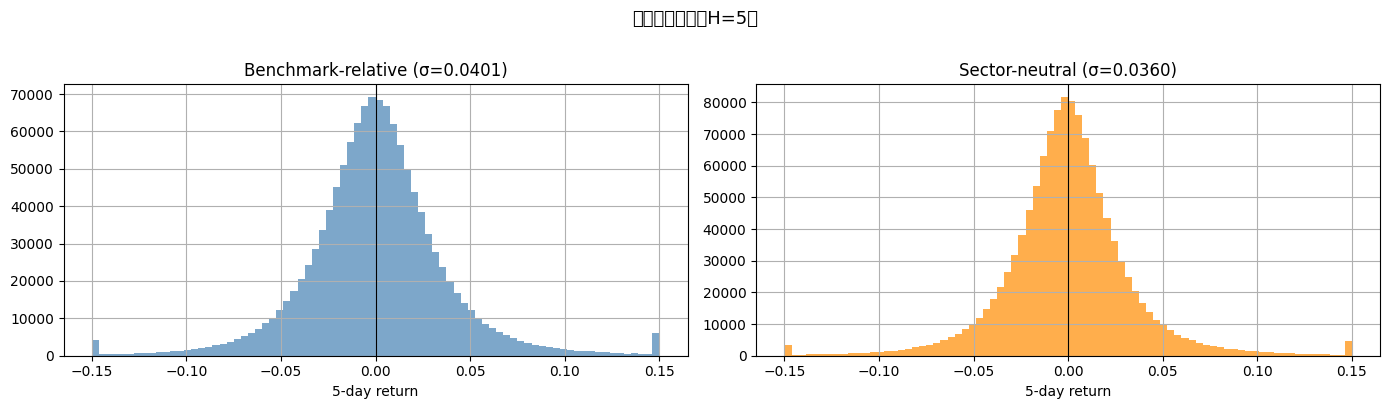

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bm_std = base_labels["benchmark_relative_open_to_open_return"].std()
sn_std = base_labels[SECTOR_NEUTRAL_LABEL].std()

for ax, col, color, label in [
    (axes[0], "benchmark_relative_open_to_open_return",
     "steelblue", f"Benchmark-relative (σ={bm_std:.4f})"),
    (axes[1], SECTOR_NEUTRAL_LABEL,
     "darkorange", f"Sector-neutral (σ={sn_std:.4f})"),
]:
    ax.hist(base_labels[col].clip(-0.15, 0.15), bins=80,
            color=color, alpha=0.7, edgecolor="none")
    ax.set_title(label)
    ax.set_xlabel("5-day return")
    ax.axvline(0, color="k", lw=0.8)

plt.suptitle("标签分布对比（H=5）", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. 数据切分：Purged Expanding Walk-Forward

**防泄漏是结果可信的前提。** 用普通 K-fold 会把未来数据泄漏给训练集，导致 OOS 表现虚高。

### 设计原则

```
[========= train =========][= gap =][= test =]  → 下一 fold
                            ↑ purge gap（60天）
```

- **Expanding**：训练集只向右扩展，不滚动——保证足够样本量（CatBoost 对样本量敏感）
- **Purge gap 60天**：标签窗口最长 H=20 天，gap 留 60 天远超标签窗口，彻底切断训练/测试的信息重叠
- **测试块 126天**：约半年，足够评估跨 regime 稳定性

### 五个 Fold 结构

| Fold | 训练期 | 测试期 | 测试市场环境 |
|---|---|---|---|
| fold_001 | 2015~2020-01 | 2020-03~09 | 新冠崩盘 + 反弹 |
| fold_002 | 2015~2020-09 | 2020-12~2021-06 | 流动性牛市 |
| fold_003 | 2015~2021-06 | 2021-09~2022-03 | 加息周期开启 |
| fold_004 | 2015~2022-03 | 2022-06~12 | 熊市 |
| fold_005 | 2015~2022-12 | 2023-03~09 | 复苏 |


In [6]:
signal_dates = base_labels["signal_date"].drop_duplicates()
folds = build_round1_walk_forward_folds(signal_dates)

validate_fold_label_windows(
    base_labels, folds,
    signal_date_column="signal_date",
    entry_date_column="entry_date",
    exit_date_column="exit_date",
)
print("标签窗口防泄漏验证通过\n")
for f in folds:
    n_train = base_labels[
        (base_labels["signal_date"] >= f.train_start) &
        (base_labels["signal_date"] <= f.train_end)
    ]["signal_date"].nunique()
    print(f"  {f.fold_id}: train {f.train_start.date()}~{f.train_end.date()} ({n_train}天)  "
          f"test {f.test_start.date()}~{f.test_end.date()}")


标签窗口防泄漏验证通过

  fold_001: train 2015-12-31~2020-01-02 (1008天)  test 2020-03-31~2020-09-28
  fold_002: train 2015-12-31~2020-09-28 (1194天)  test 2020-12-23~2021-06-24
  fold_003: train 2015-12-31~2021-06-24 (1380天)  test 2021-09-21~2022-03-21
  fold_004: train 2015-12-31~2022-03-21 (1566天)  test 2022-06-16~2022-12-14
  fold_005: train 2015-12-31~2022-12-14 (1752天)  test 2023-03-15~2023-09-13


## 6. 模型配置

**CatBoostRegressor**，浅树 + 强正则，宁欠拟合不过拟合。

| 参数 | 值 | 作用 |
|---|---|---|
| iterations | 500 | 树的数量 |
| depth | 4 | 树深度（控制复杂度） |
| learning_rate | 0.03 | 小学习率配合多棵树 |
| l2_leaf_reg | 10.0 | L2 正则 |
| min_data_in_leaf | 20 | 叶节点最少样本，防止小样本过拟合 |

每个 fold 独立训练一个模型，预测对应测试期，**训练和测试完全隔离**。


In [12]:
# 以 base_labels 为左表合并特征（只含 feat_* 列，不混入其他 label 列）
samples = base_labels.merge(feat_df, on=["signal_date", "symbol"],
                             how="left", validate="many_to_one")
samples = samples.reset_index(drop=True)
print(f"数据集：{len(samples):,} 行，{len(feat_cols)} 个特征列")
print(f"标签缺失率：{samples[SECTOR_NEUTRAL_LABEL].isna().mean():.2%}")

cb_config = CatBoostRegressorConfig()  # 与 research_sector_neutral.ipynb 保持一致
wf_config = WalkForwardPredictionConfig(
    label_column=SECTOR_NEUTRAL_LABEL,
    feature_prefix="feat_",
    n_top_features=200,
)
print("\nCatBoost 配置：", cb_config)


数据集：1,225,807 行，1547 个特征列
标签缺失率：0.00%

CatBoost 配置： CatBoostRegressorConfig(iterations=500, depth=4, learning_rate=0.03, l2_leaf_reg=10.0, min_data_in_leaf=20, random_seed=20260417, thread_count=-1, verbose=0, sample_weight_half_life_days=None)


## 7. Walk-Forward 训练与预测

每个 fold 的流程：
1. 用训练集计算每个特征的截面 Pearson IC，选 top-200
2. 在训练集上拟合 CatBoost
3. 在测试集上生成预测打分（不接触标签）
4. 汇总全部 5 个 fold 的测试期预测，评估 OOS Rank IC


In [13]:
print("开始 Walk-Forward（约5分钟）...")
predictions = run_walk_forward_predictions(
    samples, folds,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=wf_config,
)
print(f"预测完成，OOS 预测行数：{len(predictions):,}")


开始 Walk-Forward（约5分钟）...
预测完成，OOS 预测行数：310,547


## 8. OOS 结果

### 评估指标说明

每个交易日计算预测打分与标签的**截面 Spearman 相关系数（Rank IC）**，然后：

- **mean IC**：OOS 期间日均值
- **ICIR**：mean IC / std(IC)，信噪比
- **HAC t-stat**：Newey-West 自相关修正的 t 统计量（日频 IC 存在自相关，普通 t-stat 会高估显著性）
- **p 值**：H₀: mean IC ≤ 0 的单侧检验


In [14]:
pred_sn = (
    predictions
    .drop(columns=["benchmark_relative_open_to_open_return"])
    .rename(columns={SECTOR_NEUTRAL_LABEL: "benchmark_relative_open_to_open_return"})
)
panel, fold_summary, horizon_summary = evaluate_oos_rank_ic(pred_sn, folds, RankICConfig())
row = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]

# Per-fold 表
FOLD_NOTES = {
    "fold_001": "2020 新冠崩盘+反弹",
    "fold_002": "2020-21 流动性牛市",
    "fold_003": "2021-22 加息周期开启",
    "fold_004": "2022 熊市",
    "fold_005": "2023 复苏",
}
print("=== Per-Fold Rank IC ===")
print(f"{'fold_id':10s}  {'mean IC':>8s}  {'ICIR':>6s}  {'市场环境'}")
for _, r in fold_summary.iterrows():
    note = FOLD_NOTES.get(r["fold_id"], "")
    print(f"{r['fold_id']:10s}  {r['mean_rank_ic']:8.4f}  {r['icir']:6.3f}  {note}")

print(f"\n=== 全局汇总 ===")
print(f"mean Rank IC : {row['mean_rank_ic']:.4f}")
print(f"ICIR         : {row['icir']:.3f}")
print(f"HAC t-stat   : {row['hac_t_stat']:.3f}")
print(f"p (one-sided): {row['p_value_one_sided']:.4f}")


=== Per-Fold Rank IC ===
fold_id      mean IC    ICIR  市场环境
fold_001      0.0524   0.383  2020 新冠崩盘+反弹
fold_002      0.0085   0.067  2020-21 流动性牛市
fold_003     -0.0082  -0.061  2021-22 加息周期开启
fold_004      0.0038   0.033  2022 熊市
fold_005      0.0216   0.241  2023 复苏

=== 全局汇总 ===
mean Rank IC : 0.0156
ICIR         : 0.126
HAC t-stat   : 1.850
p (one-sided): 0.0322


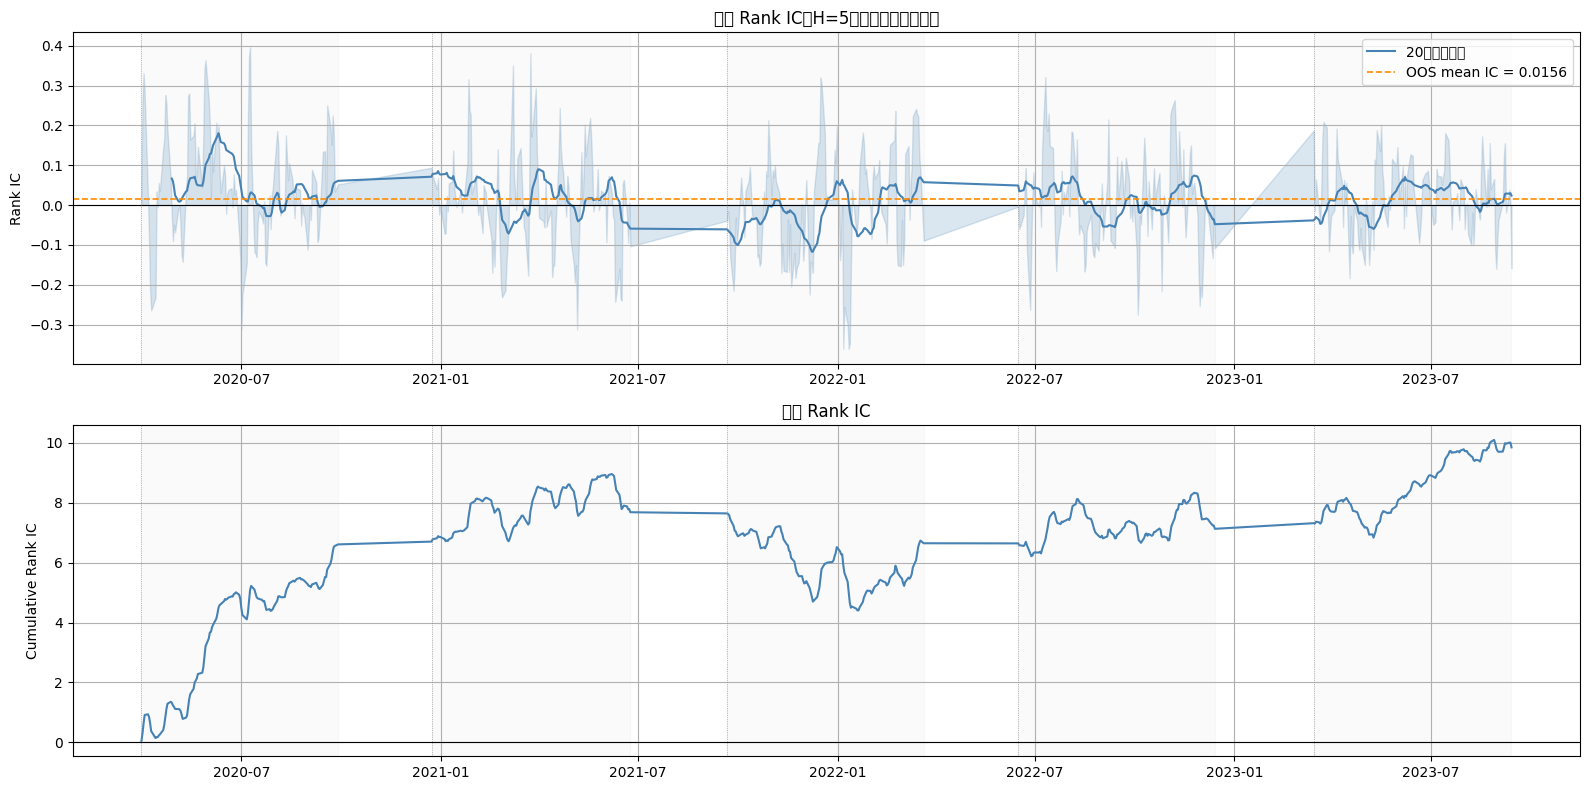

In [15]:
ic_series = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"].sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Rolling IC
rolling = ic_series.rolling(20).mean()
axes[0].fill_between(ic_series.index, 0, ic_series, alpha=0.2, color="steelblue")
axes[0].plot(rolling.index, rolling, color="steelblue", lw=1.5, label="20日滚动均值")
axes[0].axhline(row["mean_rank_ic"], color="darkorange", lw=1.2, linestyle="--",
                label=f"OOS mean IC = {row['mean_rank_ic']:.4f}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title(f"日频 Rank IC（H={HORIZON}，行业中性化标签）", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Rank IC")

# 累积 IC
axes[1].plot(ic_series.index, ic_series.cumsum(), color="steelblue", lw=1.5)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("累积 Rank IC", fontsize=12)
axes[1].set_ylabel("Cumulative Rank IC")

# Fold 分隔线
for f in folds:
    for ax in axes:
        ax.axvspan(f.test_start, f.test_end, alpha=0.04, color="gray")
        ax.axvline(f.test_start, color="gray", lw=0.5, linestyle=":")

plt.tight_layout()
plt.show()


## 9. 结论与下一步

### 核心发现

1. **纯量价信号存在，但较弱**：OOS mean IC = 0.0156，p = 0.032，刚过 5% 门槛。多重检验校正后（约7个实验，Bonferroni 阈值 0.007）仍不能确认为真实 alpha。

2. **标签设计是最高杠杆点**：换标签（benchmark-relative → sector-neutral）的提升（p: 0.054→0.032）远大于增加220个特征（p: 0.062→0.054）。


3. **已证伪的方向**：
   - Rolling window（数据量不足）
   - 样本时间衰减权重（本质同上，有效样本量压缩）

### 下一步

| 优先级 | 方向 | 预期影响 |
|---|---|---|
| 高 | 组合回测：从 IC 信号到实际多空组合收益 | 验证信号是否可交易 |
| 中 | 更细粒度行业分类（sub-industry） | 进一步降低标签噪声 |
| 低 | Cross-sectional Transformer | 捕捉截面相对关系（CatBoost做不到） |
